In [10]:
# Cellule 1 - Importer les bibliothèques
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import ttest_ind

In [11]:
# Cellule 2 - Charger les logs
log_path = Path("../logs/ab_predictions.jsonl")

df = pd.read_json(log_path, lines=True)
print(df.shape)
df.head()

(250, 5)


,user_id,variant,prediction,features,timestamp
0,alice,B,1.91478,"{'MedInc': 3.5, 'HouseAge': 20, 'AveRooms': 5,...",2026-05-11 14:41:01.600658+00:00
1,alice,B,1.91478,"{'MedInc': 3.5, 'HouseAge': 20, 'AveRooms': 5,...",2026-05-11 14:46:23.397563+00:00
2,alice,B,1.91478,"{'MedInc': 3.5, 'HouseAge': 20, 'AveRooms': 5,...",2026-05-11 14:46:29.680863+00:00
3,alice,B,1.91478,"{'MedInc': 3.5, 'HouseAge': 20, 'AveRooms': 5,...",2026-05-11 14:46:30.817944+00:00
4,alice,B,1.91478,"{'MedInc': 3.5, 'HouseAge': 20, 'AveRooms': 5,...",2026-05-11 14:46:31.610723+00:00


In [14]:
df.tail(5)

,user_id,variant,prediction,features,timestamp
245,user_96,A,2.097480,"{'MedInc': 6.02, 'HouseAge': 22.0, 'AveRooms':...",2026-05-12 09:14:13.248875+00:00
246,user_97,B,3.272291,"{'MedInc': 7.42, 'HouseAge': 37.0, 'AveRooms':...",2026-05-12 09:14:13.286258+00:00
247,user_98,B,1.474900,"{'MedInc': 3.2800000000000002, 'HouseAge': 47....",2026-05-12 09:14:13.325240+00:00
248,user_99,B,4.301593,"{'MedInc': 7.42, 'HouseAge': 31.0, 'AveRooms':...",2026-05-12 09:14:13.364744+00:00
249,test,A,1.914780,"{'MedInc': 3.5, 'HouseAge': 20, 'AveRooms': 5,...",2026-05-12 11:30:41.224137+00:00


In [3]:
# Cellule 3 - Vérifier les colonnes

df.columns

Index(['user_id', 'variant', 'prediction', 'features', 'timestamp'], dtype='str')

In [4]:
# Cellule 4 - Compter le nombre de requêtes par variante

df["variant"].value_counts()

variant
B    149
A    100
Name: count, dtype: int64

In [5]:
# Cellule 5 - Comparer les prédictions moyennes

df.groupby("variant")["prediction"].agg(["count", "mean", "std", "min", "max"])

,count,mean,std,min,max
variant,,,,,
A,100,2.316351,1.137755,0.54804,4.787277
B,149,2.292832,0.991409,0.66718,4.780258


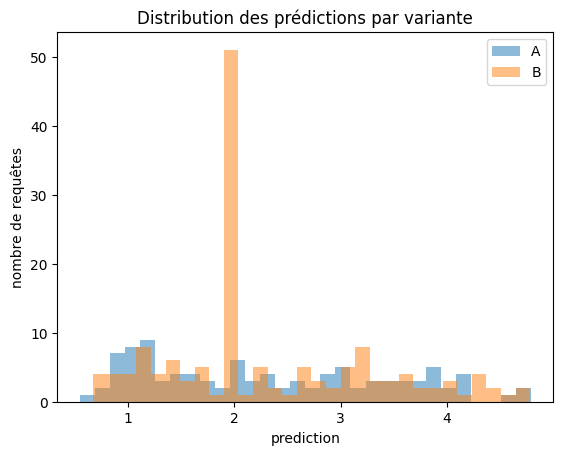

In [6]:
# Cellule 6 - Visualiser les distributions

for variant in ["A", "B"]:
    subset = df[df["variant"] == variant]
    plt.hist(subset["prediction"], alpha=0.5, bins=30, label=variant)

plt.legend()
plt.title("Distribution des prédictions par variante")
plt.xlabel("prediction")
plt.ylabel("nombre de requêtes")
plt.show()

In [2]:
# Cellule 7 - Comparer la latence

df.groupby("variant")["latency_ms"].agg(["count", "mean", "std", "max"])

NameError: name 'df' is not defined

In [1]:
# Cellule 8 - Faire un T-test sur les prédictions

group_a = df[df["variant"] == "A"]["prediction"]
group_b = df[df["variant"] == "B"]["prediction"]

stat, pvalue = ttest_ind(group_a, group_b, equal_var=False)

print("statistique =", stat)
print("p-value =", pvalue)

NameError: name 'df' is not defined

In [ ]:
# Cellule 9 : Ajouter une ground truth simulée

import numpy as np

# Simulation pédagogique d'une vérité terrain
# On suppose ici que la valeur réelle est proche de la prédiction,
# avec un bruit aléatoire ajouté.
df["actual_value"] = df["prediction"] + np.random.normal(
    loc=0,
    scale=0.3,
    size=len(df),
)

df.head()

In [ ]:
# Cellule 10 : Calculer l’erreur absolue

df["absolute_error"] = (df["actual_value"] - df["prediction"]).abs()

df.groupby("variant")["absolute_error"].agg(["count", "mean", "std"])

In [ ]:
# Cellule 11 : T-test sur l’erreur

from scipy.stats import ttest_ind

err_a = df[df["variant"] == "A"]["absolute_error"]
err_b = df[df["variant"] == "B"]["absolute_error"]